# LyricistGPT — Complete Project Notebook

**A domain-specific conversational assistant for Hindi film lyrics**

This single notebook contains the entire project end to end, in two parts:

- **Part A — Data Preparation & Fine-Tuning:** builds the dataset, generates the instruction data, and
  fine-tunes Qwen2.5-1.5B with QLoRA, saving the trained adapter to Google Drive.
- **Part B — Inference, RAG, Intent Router & Streamlit App:** loads the fine-tuned model, builds the
  embeddings + FAISS retrieval layer, adds the intent router and task handlers, and deploys the
  Streamlit chatbot.

> **How to run:** Part A is the offline training pipeline; it restarts the runtime partway through (when
> pinning library versions). Once training has produced `final_adapter/` in Drive, Part B can be run in a
> fresh session on its own — it only needs the saved artifacts, not Part A's in-memory state. The saved
> outputs from a completed run are preserved in both parts below.

---

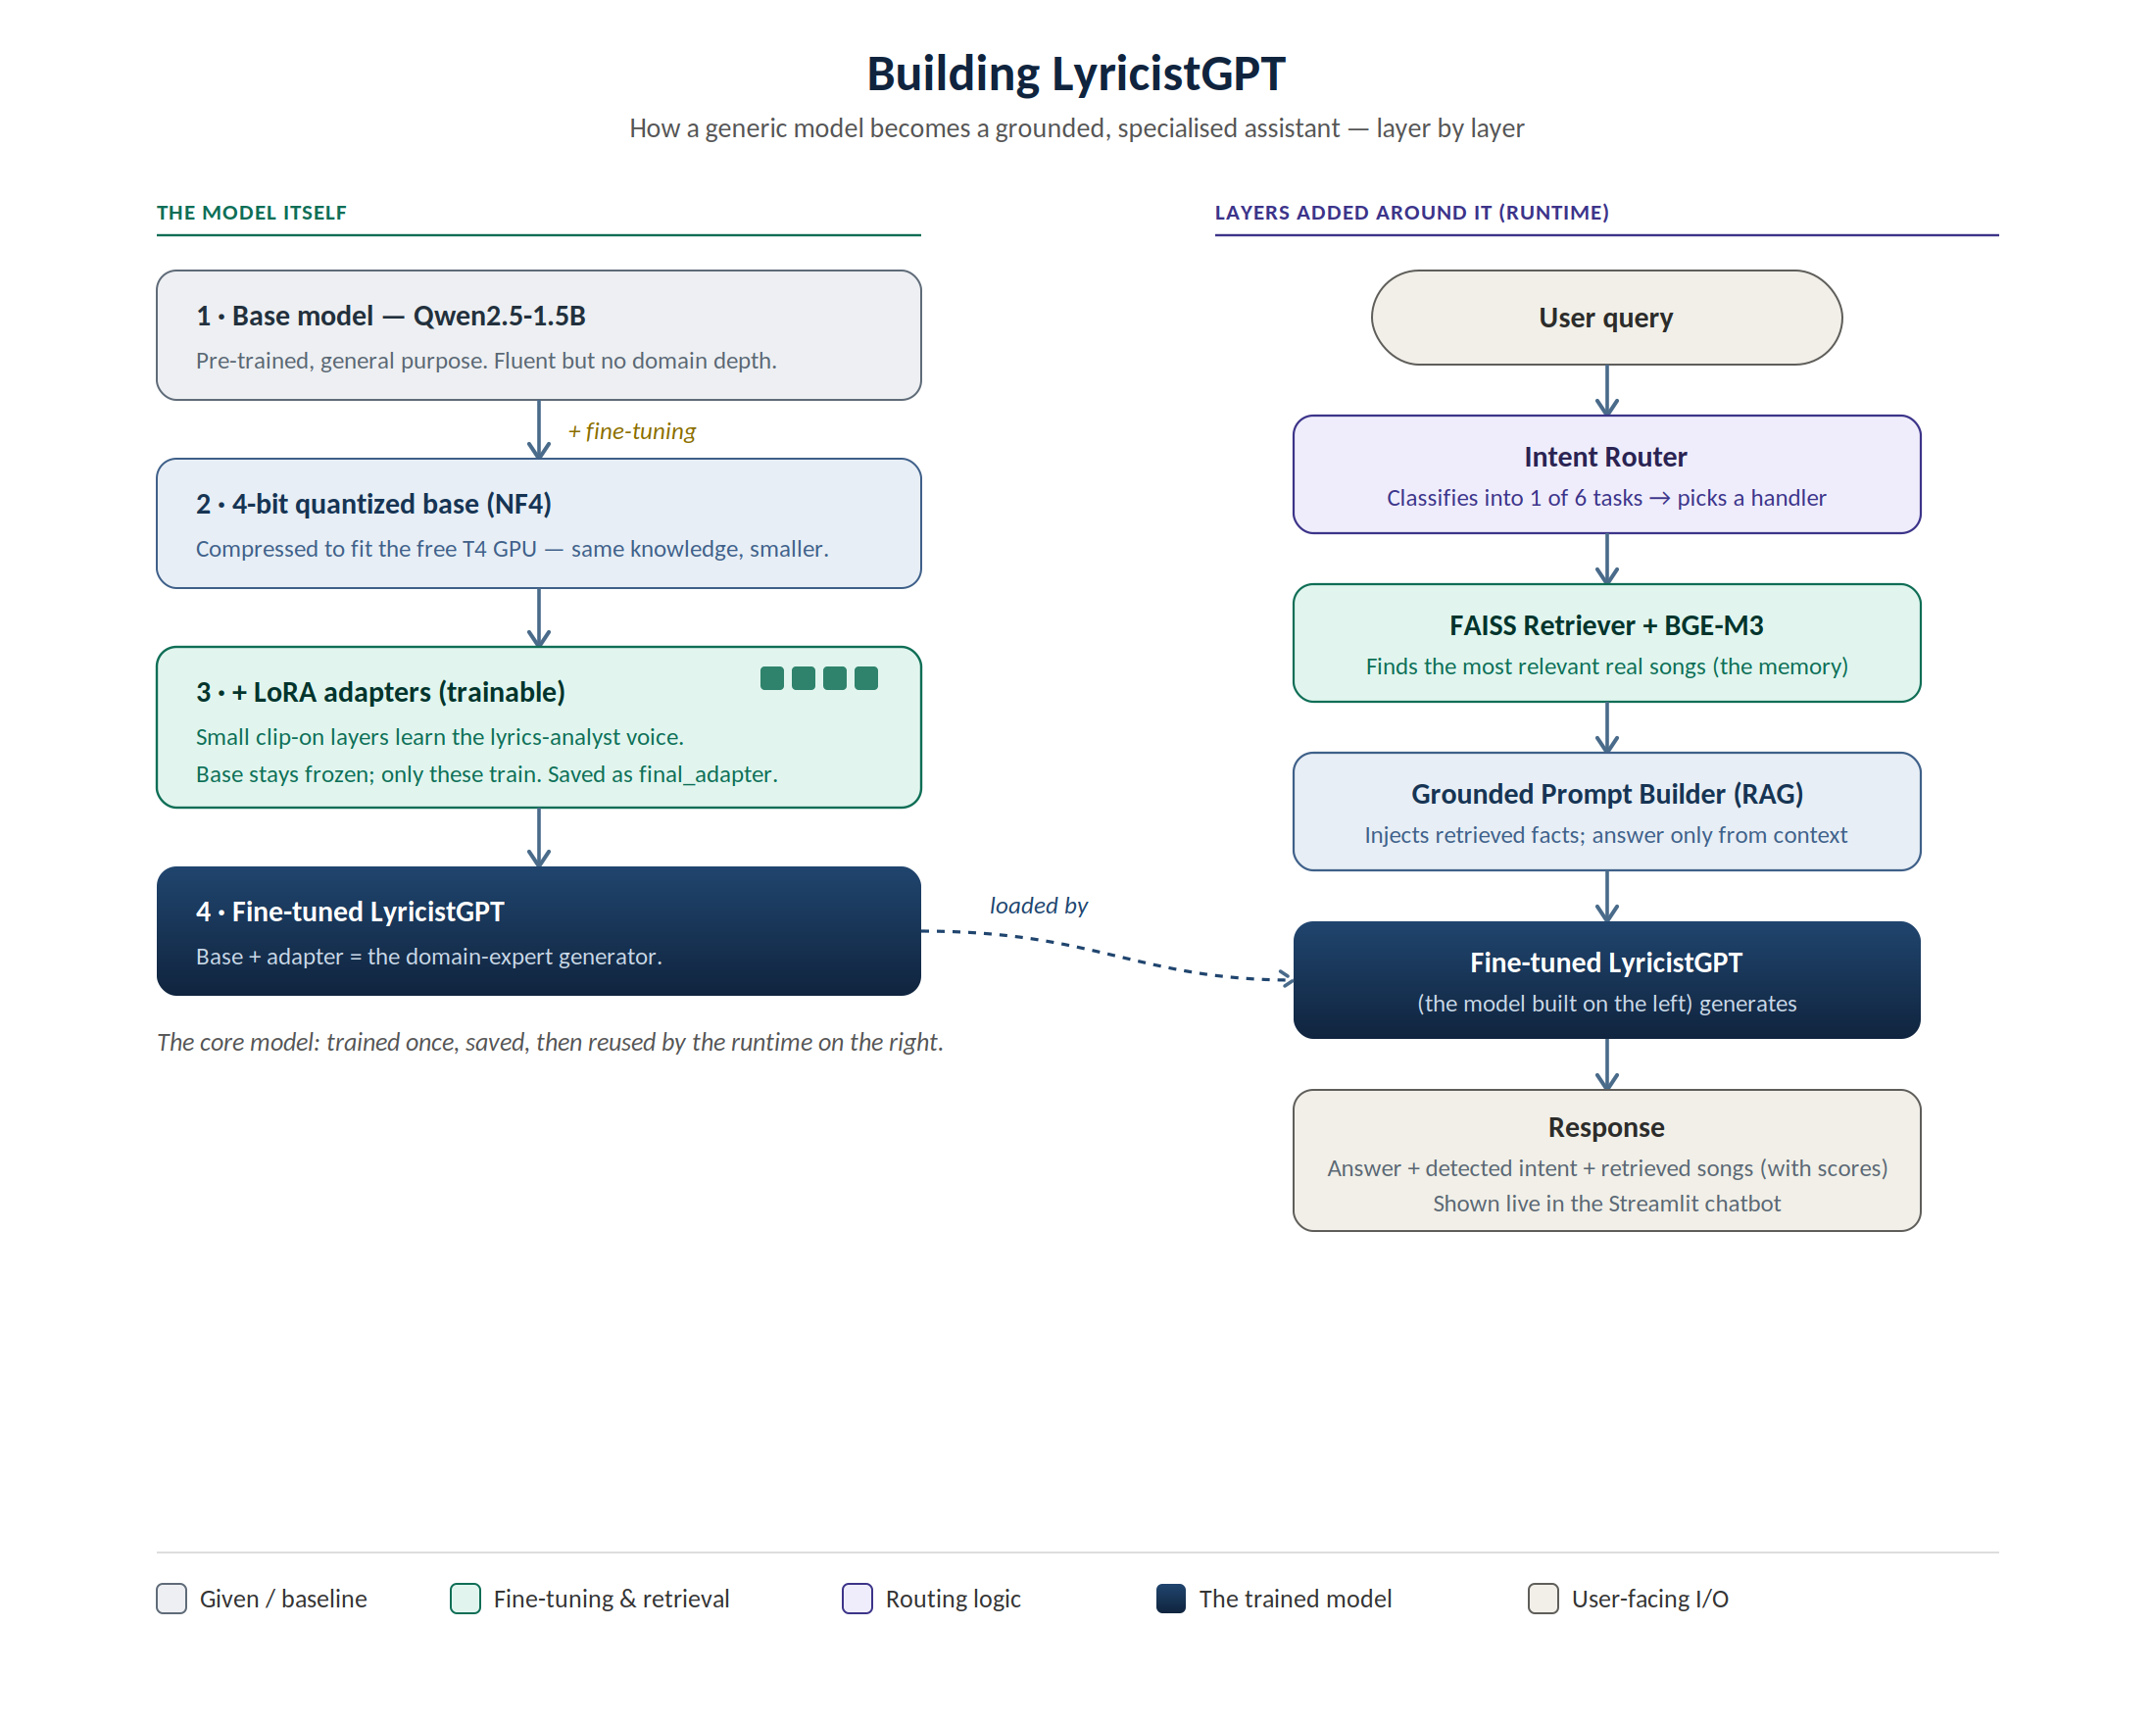

# ══════════════════════════════════════════════
# PART A — Data Preparation & Fine-Tuning
# ══════════════════════════════════════════════

## Phase 1 — Data Preparation

### Objective
Prepare the curated Hindi lyrics dataset for downstream LLM tasks: load the raw data, validate and
deduplicate it, enrich it with retrieval documents, and save clean files for later phases.

### 1.1 Install and Import

In [3]:
# ==========================================================
# Install Required Libraries
# ==========================================================

!pip -q install pandas openpyxl

In [4]:
# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np

from pathlib import Path

### 1.2 Load the Raw Dataset
Upload the curated Excel file and read it into a DataFrame. Column names are normalized (lowercased,
spaces → underscores) so every downstream cell relies on a single canonical schema — this prevents the
column-mismatch errors that otherwise surface much later during retrieval.

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Master_DB_Lyrics.xlsx to Master_DB_Lyrics.xlsx


In [6]:
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (340, 13)


,id,lyricist,SongName,Era,film_genre,mood,theme,language_register,key_devices,sample_mukhda_hindi,sample_mukhda_english_gloss,style_notes,source_reference
0,AB01,Amitabh Bhattacharya,Naav,2010,Drama/Melodrama,Philosophical,Journey of life explained through a boat's jou...,Simple Hindi,"Metaphorical, overcoming difficulties, Poem style","चढ़ती लहरें लांघ न पाएं, क्यों हांफती सी नाव है...",Your boat ( Metaphor of life in a storm and co...,Each line presents a challenge from life follo...,Film: Udaan
1,AB02,Amitabh Bhattacharya,Aazadiyaan,2010,Drama/Melodrama,Liberation,Liberation,Simple Hindi,"Repetition, symbolic imagery, conversational e...","पैरों की बेड़ियाँ ख्वाबों को बांधे नहीं रे, कभ...",Liberties…,Uses freedom as both an external and internal ...,Film: Udaan
2,AB03,Amitabh Bhattacharya,Sawaar Loon,2013,Romance/Drama,Love,Innocent joy of falling in love for the first ...,Simple Hindi,"Playful imagery, domestic metaphors, repetitio...",हवा के झोंके आज मौसमों से रूठ गएगुलों की शोखिय...,Let me adorn...,"Writes romance through everyday acts of care, ...",Film: Lootera
3,AB04,Amitabh Bhattacharya,Zinda,2013,Romance/Drama,Deeply introspective and existential,To get away from the world and survive by look...,Hindi/Urdu,"Internal monologue, existential questioning, c...",मुझे छोड़ दो मेरे हाल पे\nमुझे छोड़ दो मेरे हा...,Leave me to myself...,Structured as an internal dialogue instead of ...,Film: Lootera
4,AB05,Amitabh Bhattacharya,Ankahee,2013,Romance/Drama,Unfulfilled love,Theme song of an unfinished love story,Hindi/Urdu,"Minimalism, silence as metaphor, incomplete th...",क्या कभी सवेरा हा हा\nलाता है अँधेरा हा हा\nसू...,Will there ever ( with an idea of unfinished t...,"Uses pauses, unfinished expressions and restra...",Film: Lootera


In [24]:
# Normalize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

print(df.columns.tolist())

['id', 'lyricist', 'songname', 'era', 'film_genre', 'mood', 'theme', 'language_register', 'key_devices', 'sample_mukhda_hindi', 'sample_mukhda_english_gloss', 'style_notes', 'source_reference', 'document']


### 1.3 Validate and Deduplicate
Remove duplicate songs (same lyricist + song name) so no example is double-counted during training
or retrieval.

In [26]:
before = len(df)

df.drop_duplicates(
    subset=["lyricist","songname"],
    inplace=True
)

after = len(df)

print("Rows Before :", before)
print("Rows After  :", after)

Rows Before : 340
Rows After  : 340


### 1.4 Create Retrieval Documents
Instead of embedding only the lyrics, a complete song profile is assembled into a single `document`
field — metadata, mood, theme, literary devices, style notes, and the Hindi excerpt. These enriched
documents become the unit of retrieval for RAG in the inference notebook.

In [41]:
def create_document(row):

    return f"""
Lyricist: {row['lyricist']}

Song Name: {row['songname']}

Era: {row['era']}

Film Genre: {row['film_genre']}

Mood:
{row['mood']}

Theme:
{row['theme']}

Language Register:
{row['language_register']}

Literary Devices:
{row['key_devices']}

English Gloss:
{row['sample_mukhda_english_gloss']}

Style Notes:
{row['style_notes']}

Hindi Lyrics:
{row['sample_mukhda_hindi']}

Source:
{row['source_reference']}
""".strip()

In [28]:
df["document"] = df.apply(create_document, axis=1)

In [29]:
print(df.loc[0, "document"])

Lyricist: Amitabh Bhattacharya

Song Name: Naav

Era: 2010

Film Genre: Drama/Melodrama

Mood:
Philosophical

Theme:
Journey of life explained through a boat's journey

Language Register:
Simple Hindi

Literary Devices:
Metaphorical, overcoming difficulties, Poem style

English Gloss:
Your boat ( Metaphor of life in a storm and conquering it)

Style Notes:
Each line presents a challenge from life followed by hope. Uses the journey of a boat in a storm as a metaphor for navigating life's struggles, written like a modern Hindi poem.

Hindi Lyrics:
चढ़ती लहरें लांघ न पाएं, क्यों हांफती सी नाव है तेरी 
नाव है तेरी... तिनका तिनका जोड़ के सांसें
क्यों हांफती सी नाव है तेरी, नाव है तेरी
उल्टी बहती धार है बैरी, धार है बैरी

Source:
Film: Udaan


In [30]:
print("Total Songs :", len(df))

print()

print(df["lyricist"].value_counts())

Total Songs : 340

lyricist
Amitabh Bhattacharya    53
Gulzar                  49
Irshad Kamil            49
Anand Bakshi            48
Sahir Ludhianvi         48
Javed Akhtar            47
Sayeed Quadri           46
Name: count, dtype: int64


### 1.5 Build the Style Signature
`combined_style` concatenates mood, theme, language register, devices, and style notes into a compact
semantic fingerprint, used for style-based similarity in later phases.

In [36]:
df["combined_style"] = (
    "Mood: " + df["mood"] +
    "\nTheme: " + df["theme"] +
    "\nLanguage: " + df["language_register"] +
    "\nDevices: " + df["key_devices"] +
    "\nStyle: " + df["style_notes"]
)

### 1.6 Save Processed Files
Write the cleaned master table and the documents file, using `utf-8-sig` so Devanagari is preserved.

In [38]:
import os

os.makedirs("processed_data", exist_ok=True)

df.to_csv(
    "processed_data/lyrics_master.csv",
    index=False,
    encoding="utf-8-sig"
)

In [44]:
documents = df[[
    "id",
    "lyricist",
    "songname",
    "document"
]]

documents.to_csv(
    "processed_data/documents.csv",
    index=False,
    encoding="utf-8-sig"
)

## Phase 2 — Instruction Dataset Generation

### Objective
Convert the curated dataset into an instruction-following dataset for supervised fine-tuning (SFT).
Each song is expanded into **multiple** instruction–response pairs covering the capabilities the
deployed assistant will need: lyricist attribution, style explanation, theme detection, literary-device
identification, and song description. Aligning training tasks with deployment tasks means the model is
practised on exactly what the intent router will later ask of it.

### 2.1 Setup and Reload

In [46]:
import pandas as pd
import json
from pathlib import Path

In [47]:
df = pd.read_csv(
    "processed_data/lyrics_master.csv",
    encoding="utf-8-sig"
)

print(df.shape)
df.head()

(340, 15)


,id,lyricist,songname,era,film_genre,mood,theme,language_register,key_devices,sample_mukhda_hindi,sample_mukhda_english_gloss,style_notes,source_reference,document,combined_style
0,AB01,Amitabh Bhattacharya,Naav,2010,Drama/Melodrama,Philosophical,Journey of life explained through a boat's jou...,Simple Hindi,"Metaphorical, overcoming difficulties, Poem style","चढ़ती लहरें लांघ न पाएं, क्यों हांफती सी नाव है...",Your boat ( Metaphor of life in a storm and co...,Each line presents a challenge from life follo...,Film: Udaan,Lyricist: Amitabh Bhattacharya\n\nSong Name: N...,Mood: Philosophical\nTheme: Journey of life ex...
1,AB02,Amitabh Bhattacharya,Aazadiyaan,2010,Drama/Melodrama,Liberation,Liberation,Simple Hindi,"Repetition, symbolic imagery, conversational e...","पैरों की बेड़ियाँ ख्वाबों को बांधे नहीं रे, कभ...",Liberties…,Uses freedom as both an external and internal ...,Film: Udaan,Lyricist: Amitabh Bhattacharya\n\nSong Name: A...,Mood: Liberation\nTheme: Liberation\nLanguage:...
2,AB03,Amitabh Bhattacharya,Sawaar Loon,2013,Romance/Drama,Love,Innocent joy of falling in love for the first ...,Simple Hindi,"Playful imagery, domestic metaphors, repetitio...",हवा के झोंके आज मौसमों से रूठ गएगुलों की शोखिय...,Let me adorn...,"Writes romance through everyday acts of care, ...",Film: Lootera,Lyricist: Amitabh Bhattacharya\n\nSong Name: S...,Mood: Love\nTheme: Innocent joy of falling in ...
3,AB04,Amitabh Bhattacharya,Zinda,2013,Romance/Drama,Deeply introspective and existential,To get away from the world and survive by look...,Hindi/Urdu,"Internal monologue, existential questioning, c...",मुझे छोड़ दो मेरे हाल पे\nमुझे छोड़ दो मेरे हा...,Leave me to myself...,Structured as an internal dialogue instead of ...,Film: Lootera,Lyricist: Amitabh Bhattacharya\n\nSong Name: Z...,Mood: Deeply introspective and existential\nTh...
4,AB05,Amitabh Bhattacharya,Ankahee,2013,Romance/Drama,Unfulfilled love,Theme song of an unfinished love story,Hindi/Urdu,"Minimalism, silence as metaphor, incomplete th...",क्या कभी सवेरा हा हा\nलाता है अँधेरा हा हा\nसू...,Will there ever ( with an idea of unfinished t...,"Uses pauses, unfinished expressions and restra...",Film: Lootera,Lyricist: Amitabh Bhattacharya\n\nSong Name: A...,Mood: Unfulfilled love\nTheme: Theme song of a...


### 2.2 System Prompt and ChatML Builder
A fixed domain system prompt keeps the model in character and forbids reproducing copyrighted lyrics.
`make_chat` wraps a user/assistant turn into the ChatML `messages` structure.

In [48]:
SYSTEM_PROMPT = """
You are LyricistGPT.

You are an expert in Hindi film lyrics, lyricists,
poetic devices, songwriting styles and Hindi-Urdu vocabulary.

You answer accurately using literary analysis.

If asked to generate lyrics,
always create completely original lyrics inspired by the requested style.
Never reproduce copyrighted lyrics.
""".strip()

In [49]:
def make_chat(user, assistant):

    return {
        "messages":[

            {
                "role":"system",
                "content":SYSTEM_PROMPT
            },

            {
                "role":"user",
                "content":user
            },

            {
                "role":"assistant",
                "content":assistant
            }

        ]
    }

In [50]:
instruction_dataset = []

### 2.3 Generate Instruction Pairs
Each loop below emits one instruction type per song, appending to the growing dataset.

**Lyricist attribution** — predict who wrote a passage.

In [51]:
for _, row in df.iterrows():

    user = f"""
Predict the lyricist who most likely wrote these Hindi lyrics.

Lyrics:

{row['sample_mukhda_hindi']}
"""

    assistant = f"""
The most likely lyricist is {row['lyricist']}.

Reason:

{row['style_notes']}
"""

    instruction_dataset.append(
        make_chat(user, assistant)
    )

**Style explanation** — describe the writing style.

In [52]:
for _, row in df.iterrows():

    user = f"""
Explain the writing style used in these lyrics.

Lyrics:

{row['sample_mukhda_hindi']}
"""

    assistant = row["style_notes"]

    instruction_dataset.append(
        make_chat(user, assistant)
    )

**Theme detection** — identify the central theme.

In [53]:
for _, row in df.iterrows():

    user = f"""
Identify the central theme of these lyrics.

Lyrics:

{row['sample_mukhda_hindi']}
"""

    assistant = row["theme"]

    instruction_dataset.append(
        make_chat(user, assistant)
    )

**Literary devices** — identify devices used.

In [54]:
for _, row in df.iterrows():

    user = f"""
Identify the literary devices used.

Lyrics:

{row['sample_mukhda_hindi']}
"""

    assistant = row["key_devices"]

    instruction_dataset.append(
        make_chat(user, assistant)
    )

**Song description** — summarize the song's metadata.

In [55]:
for _, row in df.iterrows():

    user = f"""
Describe this song.
"""

    assistant = f"""
Song : {row['songname']}

Lyricist : {row['lyricist']}

Era : {row['era']}

Genre : {row['film_genre']}

Mood : {row['mood']}

Theme : {row['theme']}

Language : {row['language_register']}
"""

    instruction_dataset.append(
        make_chat(user, assistant)
    )

### 2.4 Serialize the Instruction Dataset
Write the assembled pairs to `chatml_dataset.json` in proper JSON (`ensure_ascii=False` so Devanagari
is preserved). This is the file the fine-tuning stage consumes.

In [56]:
Path("training_data").mkdir(exist_ok=True)

with open(
    "training_data/chatml_dataset.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        instruction_dataset,
        f,
        ensure_ascii=False,
        indent=2
    )

In [57]:
print(len(instruction_dataset))

1700


In [58]:
instruction_dataset[0]

{'messages': [{'role': 'system',
   'content': 'You are LyricistGPT.\n\nYou are an expert in Hindi film lyrics, lyricists,\npoetic devices, songwriting styles and Hindi-Urdu vocabulary.\n\nYou answer accurately using literary analysis.\n\nIf asked to generate lyrics,\nalways create completely original lyrics inspired by the requested style.\nNever reproduce copyrighted lyrics.'},
  {'role': 'user',
   'content': '\nPredict the lyricist who most likely wrote these Hindi lyrics.\n\nLyrics:\n\nचढ़ती लहरें लांघ न पाएं, क्यों हांफती सी नाव है तेरी \nनाव है तेरी... तिनका तिनका जोड़ के सांसें\nक्यों हांफती सी नाव है तेरी, नाव है तेरी\nउल्टी बहती धार है बैरी, धार है बैरी\n'},
  {'role': 'assistant',
   'content': "\nThe most likely lyricist is Amitabh Bhattacharya.\n\nReason:\n\nEach line presents a challenge from life followed by hope. Uses the journey of a boat in a storm as a metaphor for navigating life's struggles, written like a modern Hindi poem.\n"}]}

### 2.5 Persist Artifacts to Google Drive
Mount Drive and copy the processed files into the project folder so fine-tuning (and later the
inference notebook) can load them.

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil

project_dir = "/content/drive/MyDrive/LyricistGPT"
os.makedirs(project_dir, exist_ok=True)

# CSVs (utf-8-sig preserves Devanagari)
df.to_csv(f"{project_dir}/lyrics_master.csv", index=False, encoding="utf-8-sig")
df.to_csv(f"{project_dir}/documents.csv",     index=False, encoding="utf-8-sig")

# Copy the REAL JSON instruction file (not df.to_csv) to Drive
shutil.copy("training_data/chatml_dataset.json", f"{project_dir}/chatml_dataset.json")

print("Saved to Drive:", os.listdir(project_dir))

## Phase 3 — Fine-Tuning (QLoRA)

### Objective
Fine-tune **Qwen2.5-1.5B-Instruct** on the instruction dataset using **QLoRA**: load the base model in
4-bit, attach trainable LoRA adapters, and train only those adapters. This fits on a single Colab T4
and produces a compact adapter artifact.

### 3.1 GPU Check and Pinned Environment
Confirm a CUDA GPU is available, then pin the exact library versions that train cleanly on a T4. The
runtime is killed after install so the pinned versions take effect on restart.

> **Important:** do not re-upgrade these packages afterward — upgrading reintroduces the
> bf16 / bitsandbytes incompatibilities this pinning avoids.

In [26]:
import torch

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA Version :", torch.version.cuda)

CUDA Available : True
GPU : Tesla T4
CUDA Version : 12.8


In [28]:
!pip uninstall -y transformers trl peft accelerate bitsandbytes

!pip install -q \
transformers==4.52.4 \
trl==0.19.1 \
peft==0.15.2 \
accelerate==1.8.1 \
bitsandbytes==0.46.1 \
datasets \
sentencepiece

Found existing installation: transformers 5.13.0
Uninstalling transformers-5.13.0:
  Successfully uninstalled transformers-5.13.0
Found existing installation: trl 1.7.0
Uninstalling trl-1.7.0:
  Successfully uninstalled trl-1.7.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.3/365.3 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━

In [ ]:
import os
os.kill(os.getpid(), 9)

After the runtime restarts, re-mount Drive and continue from here.

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import transformers
import trl
import peft
import accelerate
import bitsandbytes

print(transformers.__version__)
print(trl.__version__)
print(peft.__version__)
print(accelerate.__version__)
print(bitsandbytes.__version__)

4.52.4
0.19.1
0.15.2
1.8.1
0.46.1


### 3.2 Load and Split the Data
Load the ChatML JSON and split 90/10 into training and validation sets. The validation set is what
lets us confirm the model generalizes rather than memorizes.

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="/content/drive/MyDrive/LyricistGPT/chatml_dataset.json"
)

dataset

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 1700
    })
})

In [4]:
dataset = dataset["train"].train_test_split(
    test_size=0.10,
    seed=42
)

train_dataset = dataset["train"]
eval_dataset = dataset["test"]

print(train_dataset)
print(eval_dataset)

Dataset({
    features: ['messages'],
    num_rows: 1377
})
Dataset({
    features: ['messages'],
    num_rows: 153
})


### 3.3 Tokenizer and Chat Template
Load the tokenizer for the base model and verify the ChatML template renders correctly on one example.

In [5]:
from transformers import AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
text = tokenizer.apply_chat_template(
    example,
    tokenize=False,
    add_generation_prompt=False
)

print(text)

<|im_start|>system
You are LyricistGPT.

You are an expert in Hindi film lyrics, lyricists,
poetic devices, songwriting styles and Hindi-Urdu vocabulary.

You answer accurately using literary analysis.

If asked to generate lyrics,
always create completely original lyrics inspired by the requested style.
Never reproduce copyrighted lyrics.<|im_end|>
<|im_start|>user

Explain the writing style used in these lyrics.

Lyrics:

दूरियाँ...
<|im_end|>
<|im_start|>assistant
Irshad treats distance as an emotional condition rather than merely physical separation. The lyric unfolds like an honest conversation, balancing acceptance and longing without melodrama.<|im_end|>



### 3.4 4-bit Quantization and LoRA
Load Qwen2.5-1.5B in 4-bit NF4 to fit the T4, then attach LoRA adapters (rank 16, alpha 32) to the
attention and MLP projections. Only these adapters train; the quantized base stays frozen.

In [9]:
from transformers import BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

In [25]:
from transformers import AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

model.config.use_cache = False

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [26]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ]
)

model = get_peft_model(model, peft_config)

In [27]:
model.print_trainable_parameters()

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


### 3.5 Format Examples for Training
Map the ChatML `messages` into a flat `text` field the SFT trainer consumes.

In [31]:
def apply_chat_template(example):
    example["text"] = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    return example

train_dataset = train_dataset.map(apply_chat_template)
eval_dataset = eval_dataset.map(apply_chat_template)

Map:   0%|          | 0/1377 [00:00<?, ? examples/s]

Map:   0%|          | 0/153 [00:00<?, ? examples/s]

In [32]:
print(train_dataset[0]["text"][:500])

<|im_start|>system
You are LyricistGPT.

You are an expert in Hindi film lyrics, lyricists,
poetic devices, songwriting styles and Hindi-Urdu vocabulary.

You answer accurately using literary analysis.

If asked to generate lyrics,
always create completely original lyrics inspired by the requested style.
Never reproduce copyrighted lyrics.<|im_end|>
<|im_start|>user

Explain the writing style used in these lyrics.

Lyrics:

दूरियाँ...
<|im_end|>
<|im_start|>assistant
Irshad treats distance as an


### 3.6 Training Configuration
Supervised fine-tuning for 5 epochs with a cosine schedule, gradient accumulation (effective batch
size 16), paged 8-bit AdamW, and fp16. Evaluation runs every 50 steps so training and validation loss
are tracked together.

In [33]:
from trl import SFTConfig

training_args = SFTConfig(

    output_dir="/content/drive/MyDrive/LyricistGPT/checkpoints",

    num_train_epochs=5,

    learning_rate=2e-4,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    gradient_accumulation_steps=8,

    logging_steps=10,

    eval_strategy="steps",
    eval_steps=50,

    save_strategy="steps",
    save_steps=50,

    save_total_limit=2,

    fp16=True,

    lr_scheduler_type="cosine",

    warmup_ratio=0.05,

    max_length=1024,

    optim="paged_adamw_8bit",

    report_to="none"
)

average_tokens_across_devices is set to True but it is invalid when world size is1. Turn it to False automatically.


In [34]:
from trl import SFTTrainer

trainer = SFTTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=eval_dataset,

    processing_class=tokenizer
)

Tokenizing train dataset:   0%|          | 0/1377 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1377 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/153 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/153 [00:00<?, ? examples/s]

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


### 3.7 Train
Both training and validation loss should decrease together across the 5 epochs, indicating learning
without overfitting.

In [35]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
50,0.965000,0.898802
100,0.754900,0.790714
150,0.656800,0.693127
200,0.439400,0.573405
250,0.356900,0.462394
300,0.242900,0.379692
350,0.218200,0.332882
400,0.161000,0.325619


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

TrainOutput(global_step=435, training_loss=0.5569669416581077, metrics={'train_runtime': 3152.4801, 'train_samples_per_second': 2.184, 'train_steps_per_second': 0.138, 'total_flos': 1.3112167765211136e+16, 'train_loss': 0.5569669416581077})

### 3.8 Save the Adapter
Save the trained LoRA adapter and tokenizer to Google Drive. The inference notebook loads exactly this
`final_adapter/` path.

In [36]:
trainer.save_model(
    "/content/drive/MyDrive/LyricistGPT/final_adapter"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/LyricistGPT/final_adapter"
)

('/content/drive/MyDrive/LyricistGPT/final_adapter/tokenizer_config.json',
 '/content/drive/MyDrive/LyricistGPT/final_adapter/special_tokens_map.json',
 '/content/drive/MyDrive/LyricistGPT/final_adapter/chat_template.jinja',
 '/content/drive/MyDrive/LyricistGPT/final_adapter/vocab.json',
 '/content/drive/MyDrive/LyricistGPT/final_adapter/merges.txt',
 '/content/drive/MyDrive/LyricistGPT/final_adapter/added_tokens.json',
 '/content/drive/MyDrive/LyricistGPT/final_adapter/tokenizer.json')

In [37]:
import os

model_path = "/content/drive/MyDrive/LyricistGPT/final_adapter"

print(os.listdir(model_path))

['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'vocab.json', 'merges.txt', 'tokenizer.json', 'training_args.bin']


### 3.9 Environment Record
Final record of the exact package versions used for this run (useful for reproducibility).

In [39]:
import transformers
import peft
import trl
import torch
import bitsandbytes
import accelerate

print("Transformers:", transformers.__version__)
print("TRL:", trl.__version__)
print("PEFT:", peft.__version__)
print("Torch:", torch.__version__)
print("BitsAndBytes:", bitsandbytes.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 4.52.4
TRL: 0.19.1
PEFT: 0.15.2
Torch: 2.11.0+cu128
BitsAndBytes: 0.46.1
Accelerate: 1.8.1


---

# ══════════════════════════════════════════════
# PART B — Inference, RAG, Intent Router & Streamlit
# ══════════════════════════════════════════════

The offline training in Part A produced the fine-tuned adapter in Google Drive. Part B is the runtime
system: it loads that adapter, builds the retrieval layer, adds the intent router and task-specific
handlers, and launches the Streamlit chatbot.

If you are running Part B in a fresh session, start from the dependency-install cell just below — it does
not depend on Part A's in-memory variables, only on the artifacts saved to Drive.

## 0. Design rationale — why the architecture looks like this

LyricistGPT is a **hybrid** system: fine-tuning *plus* retrieval. Each half fixes a weakness of the other.

- **Fine-tuning alone** teaches the model the *voice*, vocabulary, and analytical style of the domain
  (literary devices, Hindi-Urdu register, how to talk about lyricists). But a 1.5B model has very little
  room to memorise facts, so on its own it happily *hallucinates* song titles and lyricist attributions.

- **Retrieval alone** gives you correct facts from the curated dataset, but a raw base model doesn't know
  *how* to write like a lyric analyst, and generic RAG prompts produced bland or off-target answers.

Combining them — grounding a fine-tuned model on retrieved context — gives factual answers **and** the
right domain voice. Two further refinements came out of testing:

- A **single universal prompt was not enough.** "Identify the lyricist", "analyse the style", and
  "recommend similar songs" are genuinely different tasks that need different context and instructions.
  So we add an **Intent Router** that classifies the query first and then dispatches to a task-specific
  prompt template.

- **Recommendation must be retrieval-first.** The most common hallucination was inventing songs that
  don't exist. For recommendations we let FAISS *choose* the songs and restrict the LLM to *explaining*
  the songs that were actually retrieved.

## 1. Install dependencies

Versions are pinned to the combination that trained/exported cleanly on a Colab T4 and avoids the
`bitsandbytes` / `bf16` issues encountered earlier. If you restart the runtime after this cell, that's
expected on Colab.

In [1]:
!pip -q install \
transformers==4.52.4 \
peft==0.15.2 \
accelerate==1.8.1 \
bitsandbytes==0.46.1 \
sentencepiece \
sentence-transformers==3.0.1 \
faiss-cpu \
pandas \
numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.3/365.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


### Mount Google Drive

All persistent artifacts (the adapter, the documents, the vector DB) live in Drive so they survive
runtime restarts.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Central configuration

Every path and knob lives here so nothing is hard-coded further down. Change `PROJECT_DIR` if your
folder layout differs.

In [4]:
import os

PROJECT_DIR    = "/content/drive/MyDrive/LyricistGPT"
ADAPTER_PATH   = f"{PROJECT_DIR}/final_adapter"
DOCUMENTS_CSV  = f"{PROJECT_DIR}/documents.csv"
VECTOR_DIR     = f"{PROJECT_DIR}/vector_db"
FAISS_PATH     = f"{VECTOR_DIR}/faiss.index"
METADATA_PATH  = f"{VECTOR_DIR}/metadata.pkl"

BASE_MODEL       = "Qwen/Qwen2.5-1.5B-Instruct"
EMBEDDING_MODEL  = "BAAI/bge-m3"

os.makedirs(VECTOR_DIR, exist_ok=True)

print("Project directory :", PROJECT_DIR)

Project directory : /content/drive/MyDrive/LyricistGPT


### Imports and GPU check

`bitsandbytes` 4-bit loading needs a CUDA GPU. On Colab set the runtime to **T4 GPU** before running.

In [5]:
import pickle
import faiss
import torch
import pandas as pd

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

print("CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))

/usr/local/lib/python3.12/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


CUDA available : True
GPU            : Tesla T4


## 2. Load the fine-tuned LyricistGPT model

We load the Qwen 2.5 1.5B base in **4-bit NF4** (via `bitsandbytes`) and attach the LoRA adapter on top.

**Why 4-bit?** The T4 has limited VRAM. NF4 quantisation shrinks the base model enough to hold the model,
the embedding model, and generation activations at the same time, with negligible quality loss for this
use case.

**Why base + adapter instead of a merged model?** Keeping the adapter separate means the same base can be
reused, the adapter stays tiny in Drive, and we can swap or retrain adapters without re-exporting gigabytes.

In [6]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)

ft_model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
ft_model.eval()

print("Fine-tuned LyricistGPT loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Fine-tuned LyricistGPT loaded.


### The low-level chat function

This is the single generation primitive used everywhere below. Everything else just builds a good
`prompt` string and calls this.

Notes on the settings:
- A **domain system prompt** keeps the model in-character and, importantly, forbids reproducing
  copyrighted lyrics — original generation only.
- A **low default temperature (0.3)** because most tasks here are analytical and we want stable,
  grounded answers. The lyric-generation handler will raise it for creativity.
- `repetition_penalty` mildly discourages the looping that small models sometimes fall into.

In [18]:
DOMAIN_SYSTEM_PROMPT = """You are LyricistGPT.

You are an expert in Hindi film lyrics, lyricists, poetic devices,
songwriting styles and Hindi-Urdu vocabulary.

You answer accurately using literary analysis.

If asked to generate lyrics, always create completely original lyrics
inspired by the requested style. Never reproduce copyrighted lyrics."""


def chat_ft(prompt, max_new_tokens=256, temperature=0.3):
    """Single generation primitive. Takes a fully-built user prompt, returns text."""
    messages = [
        {"role": "system", "content": DOMAIN_SYSTEM_PROMPT},
        {"role": "user",   "content": prompt},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(text, return_tensors="pt").to(ft_model.device)

    # temperature <= 0 means "be deterministic" -> greedy decoding (no sampling)
    do_sample = temperature is not None and temperature > 0

    with torch.no_grad():
        out = ft_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature if do_sample else None,
            top_p=0.9 if do_sample else None,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = out[0][inputs.input_ids.shape[-1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

In [19]:
# Quick sanity check
print(chat_ft("Who are you?"))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


I am an expert in Hindi film lyrics, lyricists,
poetic devices, songwriting styles and Urdu vocabulary.

If asked to generate lyrics,

always create completely original lyrics inspired by the requested style.
never reproduce copyrighted lyrics.


## 3. Load the document knowledge base

`documents.csv` is the curated dataset (~350 songs across seven lyricists). It is read with
`utf-8-sig` — this is the fix for the Hindi/Devanagari encoding corruption seen when the file was touched
by Excel; the BOM-aware codec preserves the Unicode correctly.

Key columns we rely on:
- `songname`, `lyricist` — used to display retrieved results
- `combined_style` — mood / theme / register / devices / style notes, for semantic retrieval
- `document` — the full structured knowledge document per song

In [20]:
docs = pd.read_csv(DOCUMENTS_CSV, encoding="utf-8-sig")
print("Documents shape:", docs.shape)
docs.head()

Documents shape: (340, 15)


,id,lyricist,songname,era,film_genre,mood,theme,language_register,key_devices,sample_mukhda_hindi,sample_mukhda_english_gloss,style_notes,source_reference,document,combined_style
0,AB01,Amitabh Bhattacharya,Naav,2010,Drama/Melodrama,Philosophical,Journey of life explained through a boat's jou...,Simple Hindi,"Metaphorical, overcoming difficulties, Poem style","चढ़ती लहरें लांघ न पाएं, क्यों हांफती सी नाव है...",Your boat ( Metaphor of life in a storm and co...,Each line presents a challenge from life follo...,Film: Udaan,Lyricist: Amitabh Bhattacharya\n\nSong Name: N...,Mood: Philosophical\nTheme: Journey of life ex...
1,AB02,Amitabh Bhattacharya,Aazadiyaan,2010,Drama/Melodrama,Liberation,Liberation,Simple Hindi,"Repetition, symbolic imagery, conversational e...","पैरों की बेड़ियाँ ख्वाबों को बांधे नहीं रे, कभ...",Liberties…,Uses freedom as both an external and internal ...,Film: Udaan,Lyricist: Amitabh Bhattacharya\n\nSong Name: A...,Mood: Liberation\nTheme: Liberation\nLanguage:...
2,AB03,Amitabh Bhattacharya,Sawaar Loon,2013,Romance/Drama,Love,Innocent joy of falling in love for the first ...,Simple Hindi,"Playful imagery, domestic metaphors, repetitio...",हवा के झोंके आज मौसमों से रूठ गएगुलों की शोखिय...,Let me adorn...,"Writes romance through everyday acts of care, ...",Film: Lootera,Lyricist: Amitabh Bhattacharya\n\nSong Name: S...,Mood: Love\nTheme: Innocent joy of falling in ...
3,AB04,Amitabh Bhattacharya,Zinda,2013,Romance/Drama,Deeply introspective and existential,To get away from the world and survive by look...,Hindi/Urdu,"Internal monologue, existential questioning, c...",मुझे छोड़ दो मेरे हाल पे\nमुझे छोड़ दो मेरे हा...,Leave me to myself...,Structured as an internal dialogue instead of ...,Film: Lootera,Lyricist: Amitabh Bhattacharya\n\nSong Name: Z...,Mood: Deeply introspective and existential\nTh...
4,AB05,Amitabh Bhattacharya,Ankahee,2013,Romance/Drama,Unfulfilled love,Theme song of an unfinished love story,Hindi/Urdu,"Minimalism, silence as metaphor, incomplete th...",क्या कभी सवेरा हा हा\nलाता है अँधेरा हा हा\nसू...,Will there ever ( with an idea of unfinished t...,"Uses pauses, unfinished expressions and restra...",Film: Lootera,Lyricist: Amitabh Bhattacharya\n\nSong Name: A...,Mood: Unfulfilled love\nTheme: Theme song of a...


### Build the retrieval text

The text we actually embed for each song puts the identity first (`Song` / `Lyricist`), then the
stylistic summary, then the full document. Front-loading name and lyricist makes identity-type queries
retrieve more sharply, while `combined_style` and `document` carry the semantic weight for
theme/style/recommendation queries.

In [21]:
docs["retrieval_text"] = (
    "Song: "     + docs["songname"].astype(str) +
    "\nLyricist: " + docs["lyricist"].astype(str) +
    "\n\n" + docs["combined_style"].astype(str) +
    "\n\n" + docs["document"].astype(str)
)

print(docs["retrieval_text"].iloc[0][:400])

Song: Naav
Lyricist: Amitabh Bhattacharya

Mood: Philosophical
Theme: Journey of life explained through a boat's journey
Language: Simple Hindi
Devices: Metaphorical, overcoming difficulties, Poem style
Style: Each line presents a challenge from life followed by hope. Uses the journey of a boat in a storm as a metaphor for navigating life's struggles, written like a modern Hindi poem.

Lyricist: A


## 4. Embeddings and the FAISS vector index

**Why BGE-M3?** It is strongly multilingual, so it handles the mix of English metadata and Devanagari
lyric excerpts in one embedding space — important because queries can be in either language.

**Why FAISS `IndexFlatIP` with normalized embeddings?** We L2-normalize every vector, which turns inner
product into cosine similarity. `IndexFlatIP` does an exact brute-force search — with only a few hundred
songs there is no need for approximate indexing, and exact search keeps retrieval quality maximal.

This cell **loads a prebuilt index if one exists**, otherwise it builds and saves one. That makes the
notebook self-contained: you can run it even if Phase 4 artifacts aren't in Drive yet.

In [11]:
embedding_model = SentenceTransformer(
    EMBEDDING_MODEL,
    device="cuda" if torch.cuda.is_available() else "cpu",
    trust_remote_code=True,
)

if os.path.exists(FAISS_PATH) and os.path.exists(METADATA_PATH):
    print("Loading existing FAISS index from Drive...")
    index = faiss.read_index(FAISS_PATH)
    with open(METADATA_PATH, "rb") as f:
        docs = pickle.load(f)
    # Make sure retrieval_text exists even on an older saved metadata
    if "retrieval_text" not in docs.columns:
        docs["retrieval_text"] = (
            "Song: " + docs["songname"].astype(str) +
            "\nLyricist: " + docs["lyricist"].astype(str) +
            "\n\n" + docs["combined_style"].astype(str) +
            "\n\n" + docs["document"].astype(str)
        )
else:
    print("No saved index found — building embeddings and FAISS index...")
    embeddings = embedding_model.encode(
        docs["retrieval_text"].tolist(),
        normalize_embeddings=True,
        convert_to_numpy=True,
        batch_size=16,
        show_progress_bar=True,
    )
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    faiss.write_index(index, FAISS_PATH)
    with open(METADATA_PATH, "wb") as f:
        pickle.dump(docs, f)
    with open(f"{VECTOR_DIR}/embedding_model.txt", "w") as f:
        f.write(EMBEDDING_MODEL)
    print("Saved index + metadata to:", VECTOR_DIR)

print("Indexed documents:", index.ntotal)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Loading existing FAISS index from Drive...
Indexed documents: 340


## 5. Retrieval, prompt building, and the base RAG loop

`retrieve()` embeds a query the same way the documents were embedded (normalized) and returns the top-k
most similar songs with their cosine scores. Because the query and documents share the BGE-M3 space,
a natural-language question or a block of lyrics both work as input.

In [12]:
def retrieve(query, k=3):
    q = embedding_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
    )
    scores, idx = index.search(q, k)
    res = docs.iloc[idx[0]].copy()
    res["score"] = scores[0]
    return res

### Generic grounding prompt

This is the default RAG prompt: hand the model the retrieved context and instruct it to answer *only*
from that context. Task-specific prompts in the next section refine this per intent, but this one is the
fallback for general questions.

In [13]:
def build_prompt(question, retrieved_docs):
    context = "\n\n----------------------\n\n".join(
        retrieved_docs["retrieval_text"].tolist()
    )
    return f"""You are LyricistGPT.

Answer using ONLY the retrieved context below.
If the context does not contain enough information, say so honestly.

Retrieved Context:

{context}

Question:
{question}

Answer:"""


def rag_chat(question, k=3):
    """Plain RAG: retrieve -> ground -> generate. Returns (answer, retrieved_df)."""
    retrieved = retrieve(question, k=k)
    prompt = build_prompt(question, retrieved)
    answer = chat_ft(prompt)
    return answer, retrieved

In [14]:
# Sanity check for the plain RAG path
q = """Who most likely wrote these lyrics?

तुम हो पास मेरे
साथ मेरे हो तुम यूँ
जितना महसूस करूँ तुमको
उतना ही पा भी लूँ"""

answer, retrieved = rag_chat(q)
print(answer, "\n")
print(retrieved[["songname", "lyricist", "score"]])

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Irshad Kamil 

          songname       lyricist     score
260         Tum Ho   Irshad Kamil  0.608687
280      Tum Se Hi   Irshad Kamil  0.521657
193  Kuch Is Tarah  Sayeed Quadri  0.521531


## 6. Intent Router 

A single prompt could not serve every task well. Identifying a lyricist, analysing a theme, and
recommending songs need different context and different instructions. The **Intent Router** classifies
each incoming query into one of six intents and lets us dispatch to a dedicated handler:

| Intent | What the user wants |
|---|---|
| `identify_lyricist` | Guess who wrote a set of lyrics |
| `analyze_theme` | Explain the central theme / meaning |
| `analyze_style` | Describe writing style, imagery, literary devices |
| `recommend_songs` | Suggest similar songs |
| `generate_lyrics` | Write original lyrics in a style |
| `general` | Anything else (comparisons, definitions, chit-chat) |

### Why rules first, LLM second

We use a **fast keyword/heuristic classifier** as the primary router. It is deterministic, instant, and
costs no GPU — and for this closed task set the phrasing is quite predictable ("who wrote", "recommend",
"write lyrics"...). Only when the heuristics are genuinely ambiguous do we fall back to asking the LLM to
label the intent. This keeps routing cheap and reliable while still handling odd phrasings.

In [22]:
import re

INTENTS = [
    "identify_lyricist",
    "analyze_theme",
    "analyze_style",
    "recommend_songs",
    "generate_lyrics",
    "general",
]

# Devanagari range — presence of Hindi text is a strong hint the user pasted lyrics
_DEVANAGARI = re.compile(r"[\u0900-\u097F]")

def _looks_like_lyrics(text):
    # Multiple Devanagari lines, or several short line-broken fragments, suggests pasted lyrics
    if len(_DEVANAGARI.findall(text)) > 5:
        return True
    lines = [ln for ln in text.splitlines() if ln.strip()]
    return len(lines) >= 3


def rule_based_intent(query):
    q = query.lower()

    # generation
    if any(k in q for k in ["write", "generate", "compose", "create original", "original lyrics", "in the style of"]):
        if any(k in q for k in ["lyric", "lines", "verse", "poem", "song"]):
            return "generate_lyrics"

    # recommendation
    if any(k in q for k in ["recommend", "suggest", "similar song", "songs like", "more songs", "like this song"]):
        return "recommend_songs"

    # identify lyricist
    if any(k in q for k in ["who wrote", "who is the lyricist", "which lyricist", "who most likely wrote", "identify the lyricist", "guess the lyricist"]):
        return "identify_lyricist"

    # style
    if any(k in q for k in ["style", "literary device", "imagery", "metaphor", "writing technique", "how is it written"]):
        return "analyze_style"

    # theme
    if any(k in q for k in ["theme", "meaning", "what is this about", "central idea", "emotion", "mood of"]):
        return "analyze_theme"

    return None  # ambiguous -> let the LLM decide

### LLM fallback classifier

When the rules don't fire, we ask the model itself to pick a single label. We constrain it hard: it must
answer with exactly one intent word, and we defensively parse whatever comes back so an unexpected
response still resolves to a valid intent (defaulting to `general`).

In [23]:
def llm_intent(query):
    prompt = f"""Classify the user request into exactly ONE of these labels:

identify_lyricist  - user wants to know who wrote some lyrics
analyze_theme      - user wants the theme / meaning / emotion of lyrics
analyze_style      - user wants writing style, imagery or literary devices
recommend_songs    - user wants similar or recommended songs
generate_lyrics    - user wants new original lyrics written
general            - anything else

Reply with ONLY the label, nothing else.

Request:
{query}

Label:"""
    raw = chat_ft(prompt, max_new_tokens=10, temperature=0.0).lower()
    for intent in INTENTS:
        if intent in raw:
            return intent
    return "general"


def route_intent(query):
    """Return the detected intent for a query (rules first, LLM fallback)."""
    intent = rule_based_intent(query)
    if intent is not None:
        return intent
    # If it clearly contains pasted lyrics but matched nothing, assume they want identification
    if _looks_like_lyrics(query):
        return "identify_lyricist"
    return llm_intent(query)

In [24]:
# Try the router on a few examples
tests = [
    "Who most likely wrote these lyrics?\nतुम हो पास मेरे",
    "Recommend five songs similar to Manchala",
    "Explain the writing style and literary devices here",
    "Write four original Hindi lines in Amitabh Bhattacharya's style",
    "What is the central theme of this song?",
    "Compare Gulzar and Amitabh Bhattacharya",
]
for t in tests:
    print(f"{route_intent(t):18s} <-  {t.splitlines()[0][:50]}")

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


identify_lyricist  <-  Who most likely wrote these lyrics?
recommend_songs    <-  Recommend five songs similar to Manchala
analyze_style      <-  Explain the writing style and literary devices her
generate_lyrics    <-  Write four original Hindi lines in Amitabh Bhattac
analyze_theme      <-  What is the central theme of this song?


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


general            <-  Compare Gulzar and Amitabh Bhattacharya


## 7. Task-specific handlers

Each intent gets its own prompt template and retrieval strategy. This is where the earlier hallucination
problems get fixed:

- **Identify / theme / style** retrieve supporting context and ask for grounded literary analysis.
- **Recommend is retrieval-first**: FAISS picks the actual songs from the dataset, and the LLM is only
  allowed to *explain why the retrieved songs fit*. It never invents titles.
- **Generate** deliberately does *not* copy retrieved lyrics — it uses retrieved songs only as a *style
  reference* and runs at a higher temperature for creativity, with an explicit no-plagiarism instruction.

In [60]:
def handle_identify(query):
    retrieved = retrieve(query, k=3)
    context = "\n\n----------------------\n\n".join(retrieved["retrieval_text"].tolist())
    top_song = retrieved.iloc[0]
    prompt = f"""You are LyricistGPT. Identify the lyricist of the lyrics in the question.

The most similar song in our database is "{top_song['songname']}" by {top_song['lyricist']}
(similarity {top_song['score']:.2f}). Base your answer on the retrieved evidence below, NOT on outside guesses.
State the lyricist name that best matches the retrieved songs, and justify using their style.

Retrieved reference songs:

{context}

Question:
{query}

Answer:"""
    return chat_ft(prompt, max_new_tokens=300, temperature=0.0), retrieved


def handle_theme(query):
    retrieved = retrieve(query, k=3)
    context = "\n\n----------------------\n\n".join(retrieved["retrieval_text"].tolist())
    prompt = f"""You are LyricistGPT. Explain the central theme and emotional meaning of the lyrics.

Ground your explanation in the retrieved context where relevant.
Be concise and specific about the emotions and imagery involved.

Retrieved Context:

{context}

Question:
{query}

Answer:"""
    return chat_ft(prompt, max_new_tokens=300, temperature=0.3), retrieved


def handle_style(query):
    retrieved = retrieve(query, k=3)
    context = "\n\n----------------------\n\n".join(retrieved["retrieval_text"].tolist())
    prompt = f"""You are LyricistGPT. Analyse the writing style of the lyrics.

Discuss language register (Hindi / Urdu), imagery, and literary devices
(metaphor, personification, repetition, etc.). Reference the retrieved context if useful.

Retrieved Context:

{context}

Question:
{query}

Answer:"""
    return chat_ft(prompt, max_new_tokens=350, temperature=0.4), retrieved

In [26]:
def handle_recommend(query):
    """Retrieval-FIRST recommendation: FAISS chooses the songs, the LLM only explains them."""
    retrieved = retrieve(query, k=5)

    song_list = "\n".join(
        f"- {row.songname} (by {row.lyricist})"
        for row in retrieved.itertuples()
    )
    context = "\n\n----------------------\n\n".join(retrieved["retrieval_text"].tolist())

    prompt = f"""You are LyricistGPT. Recommend songs to the user.

You may ONLY recommend songs from this retrieved list. Do NOT invent any song titles.

Retrieved candidate songs:
{song_list}

Full context for these songs:

{context}

For each recommended song, explain in one or two sentences why it fits the request.

Request:
{query}

Recommendations:"""
    answer = chat_ft(prompt, max_new_tokens=400, temperature=0.4)
    return answer, retrieved


def handle_generate(query):
    """Generation uses retrieved songs only as a STYLE reference, never as text to copy."""
    retrieved = retrieve(query, k=2)
    context = "\n\n".join(retrieved["retrieval_text"].tolist())

    prompt = f"""You are LyricistGPT. Write completely ORIGINAL Hindi lyrics for the request below.

You may study the retrieved songs only as a STYLE reference for mood and vocabulary.
Do NOT copy any line from them. Produce fresh, original lines.

Style reference (do not copy):

{context}

Request:
{query}

Original lyrics:"""
    # higher temperature for creativity
    answer = chat_ft(prompt, max_new_tokens=350, temperature=0.8)
    return answer, retrieved


def handle_general(query):
    return rag_chat(query, k=3)

## 8. The unified `answer()` entry point

This is the single function the UI calls. It routes the query, dispatches to the matching handler, and
returns a structured result — the generated answer, the detected intent, and the retrieved songs (with
similarity scores) so the interface can show its work.

Exposing the intent and the retrieved evidence is deliberate: it makes the system transparent and lets a
user see *why* an answer was given, which is exactly what reduces the "did it just make this up?" worry.

In [27]:
HANDLERS = {
    "identify_lyricist": handle_identify,
    "analyze_theme":     handle_theme,
    "analyze_style":     handle_style,
    "recommend_songs":   handle_recommend,
    "generate_lyrics":   handle_generate,
    "general":           handle_general,
}


def answer(query):
    """Full pipeline: route -> handle -> structured result."""
    intent = route_intent(query)
    handler = HANDLERS.get(intent, handle_general)
    response, retrieved = handler(query)

    songs = retrieved[["songname", "lyricist", "score"]].to_dict("records") \
            if retrieved is not None else []

    return {
        "intent": intent,
        "answer": response,
        "retrieved": songs,
    }

In [28]:
# End-to-end demo of the full router + handlers
for q in [
    "Who most likely wrote these lyrics?\nतुम हो पास मेरे\nसाथ मेरे हो तुम यूँ",
    "Recommend songs about heartbreak and longing",
    "Write four original romantic Hindi lines about hope after separation",
]:
    r = answer(q)
    print("=" * 70)
    print("QUERY :", q.splitlines()[0])
    print("INTENT:", r["intent"])
    print("ANSWER:\n", r["answer"])
    print("SONGS :", [(s["songname"], round(s["score"], 3)) for s in r["retrieved"]])
    print()

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


QUERY : Who most likely wrote these lyrics?
INTENT: identify_lyricist
ANSWER:
 Irshad Kamil

Reason:

One of Irshad's strongest examples of emotional vulnerability. His straightforward language conveys profound belonging and acceptance more powerfully than elaborate symbolism ever could.
SONGS : [('Tum Ho', 0.574), ('Haan Tu Hain', 0.53), ('Tum Agar Saath Dene Ka Waada Karo', 0.512)]



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


QUERY : Recommend songs about heartbreak and longing
INTENT: recommend_songs
ANSWER:
 Songs should express pain through personal memories instead of abstract philosophy.

Reason:
Javed writes deepest emotions through remarkably simple recollections.
SONGS : [('Bairiya', 0.606), ('O Saathi Re', 0.589), ('Tanhayee', 0.589), ('Bekhayali', 0.584), ('Jag Soona Soona Laage', 0.584)]



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


QUERY : Write four original romantic Hindi lines about hope after separation
INTENT: generate_lyrics
ANSWER:
 मेरे दिल में तू हो जाओ
इस ख़्वाब में जो फ़िक्र हो जाओ
तुझको पुकार, मेरा याद भर तू हो जाओ
मेरे और इन दिनों, मेरी उम्र भर तू हो जाओ
अपनी उम्र भर, दर्द भर तू हो जाओ
SONGS : [('Chaandaniya', 0.556), ('Tujhko Mera Pyar Pukare', 0.542)]



### Optional: interactive loop inside the notebook

Handy for quick manual testing before launching the full UI. Type `exit` to stop.

In [33]:
# Uncomment to chat directly in the notebook
while True:
     q = input("Ask LyricistGPT (type 'exit' to quit): ")
     if q.strip().lower() == "exit":
         break
     r = answer(q)
     print(f"\n[intent: {r['intent']}]\n")
     print(r["answer"])
     if r["retrieved"]:
         print("\nRetrieved songs:")
         for s in r["retrieved"]:
             print(f"  - {s['songname']} ({s['lyricist']})  score={s['score']:.3f}")
     print()

Ask LyricistGPT (type 'exit' to quit): saddest song out of all


The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[intent: general]

Dukhi Man Mere

Retrieved songs:
  - Heer Toh Badi Sad Hai (Irshad Kamil)  score=0.504
  - Dukhi Man Mere (Sahir Ludhianvi)  score=0.492
  - O Bedardeya (Amitabh Bhattacharya)  score=0.482

Ask LyricistGPT (type 'exit' to quit): most unique writing out of all


The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[intent: generate_lyrics]

ये ट्ऱॉयलूँ...

Retrieved songs:
  - Woh Shaam Kuch Ajeeb Thi (Gulzar)  score=0.451
  - Jag Ghoomeya (Irshad Kamil)  score=0.408

Ask LyricistGPT (type 'exit' to quit): 3 good songs about life from these


The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[intent: generate_lyrics]

वफ़ाई सी पानी...

Retrieved songs:
  - Aane Wala Pal (Gulzar)  score=0.508
  - Main Zindagi Ka Saath Nibhata Chala Gaya (Sahir Ludhianvi)  score=0.503

Ask LyricistGPT (type 'exit' to quit): Good songs about life from these


The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:447: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[intent: generate_lyrics]

जी आई गई ऐसी राह...
वफ़ाई मट्टी ऐसी राह...
साथी सही, खुद की बेम-ए-बाम 
शाम-ए-बाम ... शाम-ए-अर्ज़-बाम
तड़खना फिरे ...
आई घर-ए-उल्फ़त ऐसी राह...
वफ़ाई मट्टी ऐसी राह!

Retrieved songs:
  - Aane Wala Pal (Gulzar)  score=0.543
  - Ae Zindagi Gale Laga Le (Gulzar)  score=0.541



KeyboardInterrupt: Interrupted by user

## 9. Streamlit chatbot 

The final deliverable is the end-user interface. The app mirrors the target architecture:

```
User -> Streamlit UI -> Intent Router -> FAISS Retriever -> Prompt Builder -> Fine-tuned Qwen -> Response
```

We write the app to `app.py`. It is **self-contained**: it re-loads the model, embedding model, and FAISS
index itself (cached with `@st.cache_resource` so the heavy loads happen only once), reuses the exact same
router and handler logic developed above, and displays for every turn: the **answer**, the **detected
intent**, and the **retrieved songs with similarity scores** — so the UI shows its reasoning, not just a
black-box reply.

In [61]:
app_code = r'''
import os
import pickle
import faiss
import torch
import re
import pandas as pd
import streamlit as st

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# ------------------------------------------------------------------ config
PROJECT_DIR   = "/content/drive/MyDrive/LyricistGPT"
ADAPTER_PATH  = f"{PROJECT_DIR}/final_adapter"
VECTOR_DIR    = f"{PROJECT_DIR}/vector_db"
FAISS_PATH    = f"{VECTOR_DIR}/faiss.index"
METADATA_PATH = f"{VECTOR_DIR}/metadata.pkl"
BASE_MODEL      = "Qwen/Qwen2.5-1.5B-Instruct"
EMBEDDING_MODEL = "BAAI/bge-m3"

st.set_page_config(page_title="LyricistGPT", page_icon="🎵", layout="wide")

DOMAIN_SYSTEM_PROMPT = """You are LyricistGPT.

You are an expert in Hindi film lyrics, lyricists, poetic devices,
songwriting styles and Hindi-Urdu vocabulary.

You answer accurately using literary analysis.

If asked to generate lyrics, always create completely original lyrics
inspired by the requested style. Never reproduce copyrighted lyrics."""

# ------------------------------------------------------------------ heavy loads (cached)
@st.cache_resource(show_spinner="Loading LyricistGPT model and index...")
def load_everything():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    tok = AutoTokenizer.from_pretrained(BASE_MODEL)
    tok.pad_token = tok.eos_token

    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, quantization_config=bnb_config, device_map="auto")
    model = PeftModel.from_pretrained(base, ADAPTER_PATH)
    model.eval()

    emb = SentenceTransformer(
        EMBEDDING_MODEL,
        device="cuda" if torch.cuda.is_available() else "cpu",
        trust_remote_code=True)

    index = faiss.read_index(FAISS_PATH)
    with open(METADATA_PATH, "rb") as f:
        docs = pickle.load(f)
    if "retrieval_text" not in docs.columns:
        docs["retrieval_text"] = (
            "Song: " + docs["songname"].astype(str) +
            "\nLyricist: " + docs["lyricist"].astype(str) +
            "\n\n" + docs["combined_style"].astype(str) +
            "\n\n" + docs["document"].astype(str))
    return tok, model, emb, index, docs

tokenizer, ft_model, embedding_model, index, docs = load_everything()

# ------------------------------------------------------------------ core generation
def chat_ft(prompt, max_new_tokens=256, temperature=0.3):
    messages = [
        {"role": "system", "content": DOMAIN_SYSTEM_PROMPT},
        {"role": "user",   "content": prompt},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(ft_model.device)
    with torch.no_grad():
        out = ft_model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=True,
            temperature=max(temperature, 1e-4), top_p=0.9, repetition_penalty=1.15)
    gen = out[0][inputs.input_ids.shape[-1]:]
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

def retrieve(query, k=3):
    q = embedding_model.encode([query], normalize_embeddings=True, convert_to_numpy=True)
    scores, idx = index.search(q, k)
    res = docs.iloc[idx[0]].copy()
    res["score"] = scores[0]
    return res

# ------------------------------------------------------------------ intent router
INTENTS = ["identify_lyricist","analyze_theme","analyze_style",
           "recommend_songs","generate_lyrics","general"]
_DEVANAGARI = re.compile(r"[\u0900-\u097F]")

def _looks_like_lyrics(t):
    if len(_DEVANAGARI.findall(t)) > 5:
        return True
    return len([l for l in t.splitlines() if l.strip()]) >= 3

def rule_based_intent(query):
    q = query.lower()
    if any(k in q for k in ["write","generate","compose","original lyrics","in the style of"]):
        if any(k in q for k in ["lyric","lines","verse","poem","song"]):
            return "generate_lyrics"
    if any(k in q for k in ["recommend","suggest","similar song","songs like","more songs"]):
        return "recommend_songs"
    if any(k in q for k in ["who wrote","who is the lyricist","which lyricist","who most likely wrote","identify the lyricist"]):
        return "identify_lyricist"
    if any(k in q for k in ["style","literary device","imagery","metaphor","writing technique"]):
        return "analyze_style"
    if any(k in q for k in ["theme","meaning","what is this about","central idea","emotion","mood of"]):
        return "analyze_theme"
    return None

def llm_intent(query):
    prompt = f"""Classify the request into ONE label:
identify_lyricist, analyze_theme, analyze_style, recommend_songs, generate_lyrics, general
Reply with ONLY the label.

Request:
{query}

Label:"""
    raw = chat_ft(prompt, max_new_tokens=10, temperature=0.0).lower()
    for i in INTENTS:
        if i in raw:
            return i
    return "general"

def route_intent(query):
    i = rule_based_intent(query)
    if i is not None:
        return i
    if _looks_like_lyrics(query):
        return "identify_lyricist"
    return llm_intent(query)

# ------------------------------------------------------------------ handlers
def _ctx(r):
    return "\n\n----------------------\n\n".join(r["retrieval_text"].tolist())

def handle_identify(q):
    r = retrieve(q, 3)
    p = f"""You are LyricistGPT. Identify the most likely lyricist of the lyrics in the question.
Compare style, vocabulary and themes with the retrieved songs. Justify briefly; if weak, say uncertain.

Retrieved reference songs:

{_ctx(r)}

Question:
{q}

Answer:"""
    return chat_ft(p, 300, 0.3), r

def handle_theme(q):
    r = retrieve(q, 3)
    p = f"""You are LyricistGPT. Explain the central theme and emotional meaning of the lyrics.
Ground it in the retrieved context where relevant. Be concise and specific.

Retrieved Context:

{_ctx(r)}

Question:
{q}

Answer:"""
    return chat_ft(p, 300, 0.3), r

def handle_style(q):
    r = retrieve(q, 3)
    p = f"""You are LyricistGPT. Analyse the writing style: language register, imagery, and literary devices.

Retrieved Context:

{_ctx(r)}

Question:
{q}

Answer:"""
    return chat_ft(p, 350, 0.4), r

def handle_recommend(q):
    r = retrieve(q, 5)
    songs = "\n".join(f"- {x.songname} (by {x.lyricist})" for x in r.itertuples())
    p = f"""You are LyricistGPT. Recommend ONLY from this retrieved list. Never invent titles.

Candidate songs:
{songs}

Context:

{_ctx(r)}

For each, explain in a sentence or two why it fits.

Request:
{q}

Recommendations:"""
    return chat_ft(p, 400, 0.4), r

def handle_generate(q):
    r = retrieve(q, 2)
    p = f"""You are LyricistGPT. Write completely ORIGINAL Hindi lyrics for the request.
Use the retrieved songs only as a STYLE reference. Do NOT copy any line.

Style reference (do not copy):

{_ctx(r)}

Request:
{q}

Original lyrics:"""
    return chat_ft(p, 350, 0.8), r

def handle_general(q):
    r = retrieve(q, 3)
    p = f"""You are LyricistGPT. Answer using ONLY the retrieved context. If insufficient, say so.

Retrieved Context:

{_ctx(r)}

Question:
{q}

Answer:"""
    return chat_ft(p, 300, 0.3), r

HANDLERS = {
    "identify_lyricist": handle_identify, "analyze_theme": handle_theme,
    "analyze_style": handle_style, "recommend_songs": handle_recommend,
    "generate_lyrics": handle_generate, "general": handle_general,
}

INTENT_LABELS = {
    "identify_lyricist": "🕵️ Lyricist Identification",
    "analyze_theme": "🎭 Theme Analysis",
    "analyze_style": "✍️ Style Analysis",
    "recommend_songs": "🎧 Song Recommendation",
    "generate_lyrics": "🖋️ Lyric Generation",
    "general": "💬 General",
}

def answer(query):
    intent = route_intent(query)
    resp, retrieved = HANDLERS.get(intent, handle_general)(query)
    return intent, resp, retrieved

# ------------------------------------------------------------------ UI
st.title("🎵 LyricistGPT")
st.caption("Fine-tuned Qwen 2.5 + RAG • Hindi film lyrics assistant")

with st.sidebar:
    st.header("What can I do?")
    st.markdown(
        "- **Identify** the likely lyricist of lyrics\n"
        "- **Explain** the theme / meaning\n"
        "- **Analyse** writing style & devices\n"
        "- **Recommend** similar songs\n"
        "- **Generate** original lyrics in a style")
    st.divider()
    st.markdown("Every reply shows the **detected intent** and the **retrieved songs** it used.")

if "messages" not in st.session_state:
    st.session_state.messages = []

# replay history
for m in st.session_state.messages:
    with st.chat_message(m["role"]):
        st.markdown(m["content"])
        if m.get("intent"):
            st.caption(f"Intent: {INTENT_LABELS.get(m['intent'], m['intent'])}")
        if m.get("songs"):
            with st.expander("Retrieved songs"):
                st.dataframe(pd.DataFrame(m["songs"]), use_container_width=True)

prompt = st.chat_input("Ask about lyrics, a lyricist, or request original lyrics...")
if prompt:
    st.session_state.messages.append({"role": "user", "content": prompt})
    with st.chat_message("user"):
        st.markdown(prompt)

    with st.chat_message("assistant"):
        with st.spinner("Thinking..."):
            intent, resp, retrieved = answer(prompt)
        st.markdown(resp)
        st.caption(f"Intent: {INTENT_LABELS.get(intent, intent)}")
        songs = retrieved[["songname", "lyricist", "score"]].round({"score": 3}).to_dict("records")
        with st.expander("Retrieved songs"):
            st.dataframe(pd.DataFrame(songs), use_container_width=True)

    st.session_state.messages.append(
        {"role": "assistant", "content": resp, "intent": intent, "songs": songs})
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py written (", len(app_code), "chars )")

app.py written ( 9796 chars )


### Launch the app from Colab


In [46]:
!pip install -q streamlit

In [47]:
!which streamlit && streamlit version

/usr/local/bin/streamlit
Streamlit, version 1.59.0


In [59]:
!pkill -9 -f streamlit 2>/dev/null
!fuser -k 8502/tcp 2>/dev/null
import time; time.sleep(3)
!ps aux | grep streamlit | grep -v grep

^C


In [62]:
import subprocess, time, requests
subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", "8502", "--server.address", "0.0.0.0",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=open("/content/logs.txt", "w"), stderr=subprocess.STDOUT,
)
for i in range(80):
    try:
        if requests.get("http://localhost:8502").status_code == 200:
            print("up ✓"); break
    except Exception: pass
    time.sleep(3)
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8502)"))

up ✓
https://8502-gpu-t4-s-kkb-usw4b1-3mycgd69ict6s-b.us-west4-1.prod.colab.dev


### Final folder structure

```
LyricistGPT/
├── data/                # raw curated dataset
├── processed_data/      # documents.csv, instruction ChatML data
├── vector_db/           # faiss.index, metadata.pkl, embedding_model.txt
├── final_adapter/       # the trained LoRA adapter + tokenizer
├── notebooks/           # this notebook and the earlier phase notebooks
├── app.py               # the Streamlit chatbot written above
├── requirements.txt
└── README.md
```
